# Task 6: House Price Prediction

**Objective:** Predict house prices using property features such as size, bedrooms, and location.

**Dataset:** California Housing Dataset (from sklearn — mirrors real Kaggle House Price data structure)

# Task 6: House Price Prediction

**Objective:** Predict house prices using property features such as size, bedrooms, and location.

**Dataset:** California Housing Dataset (from sklearn — mirrors real Kaggle House Price data structure)

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
print("Libraries imported successfully!")

Libraries imported successfully!


## Step 2: Load Dataset

In [2]:
# California Housing Dataset (real-world housing data)
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print(f"Dataset shape: {df.shape}")
print()
print("Feature descriptions:")
for i, (name, desc) in enumerate(zip(housing.feature_names, housing.DESCR.split("\n")[17:25])):
    print(f"  {name}: {desc.strip()}")
print()
print("First 5 rows:")
df.head()

Dataset shape: (20640, 9)

Feature descriptions:
  MedInc: - AveOccup      average number of household members
  HouseAge: - Latitude      block group latitude
  AveRooms: - Longitude     block group longitude
  AveBedrms: 
  Population: :Missing Attribute Values: None
  AveOccup: 
  Latitude: This dataset was obtained from the StatLib repository.
  Longitude: https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Step 3: Data Inspection & Cleaning

**Dataset Features:**
- `MedInc`: Median income in block group
- `HouseAge`: Median house age  
- `AveRooms`: Average rooms per household
- `AveBedrms`: Average bedrooms per household
- `Population`: Block group population
- `AveOccup`: Average occupants per household
- `Latitude / Longitude`: Geographic location
- `MedHouseVal`: **Target** — Median house value (in $100,000s)

In [3]:
print("=== Dataset Info ===")
df.info()
print()
print(f"Missing values: {df.isnull().sum().sum()}")
print()
print("=== Statistical Summary ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Missing values: 0

=== Statistical Summary ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Step 4: Exploratory Data Analysis (EDA)

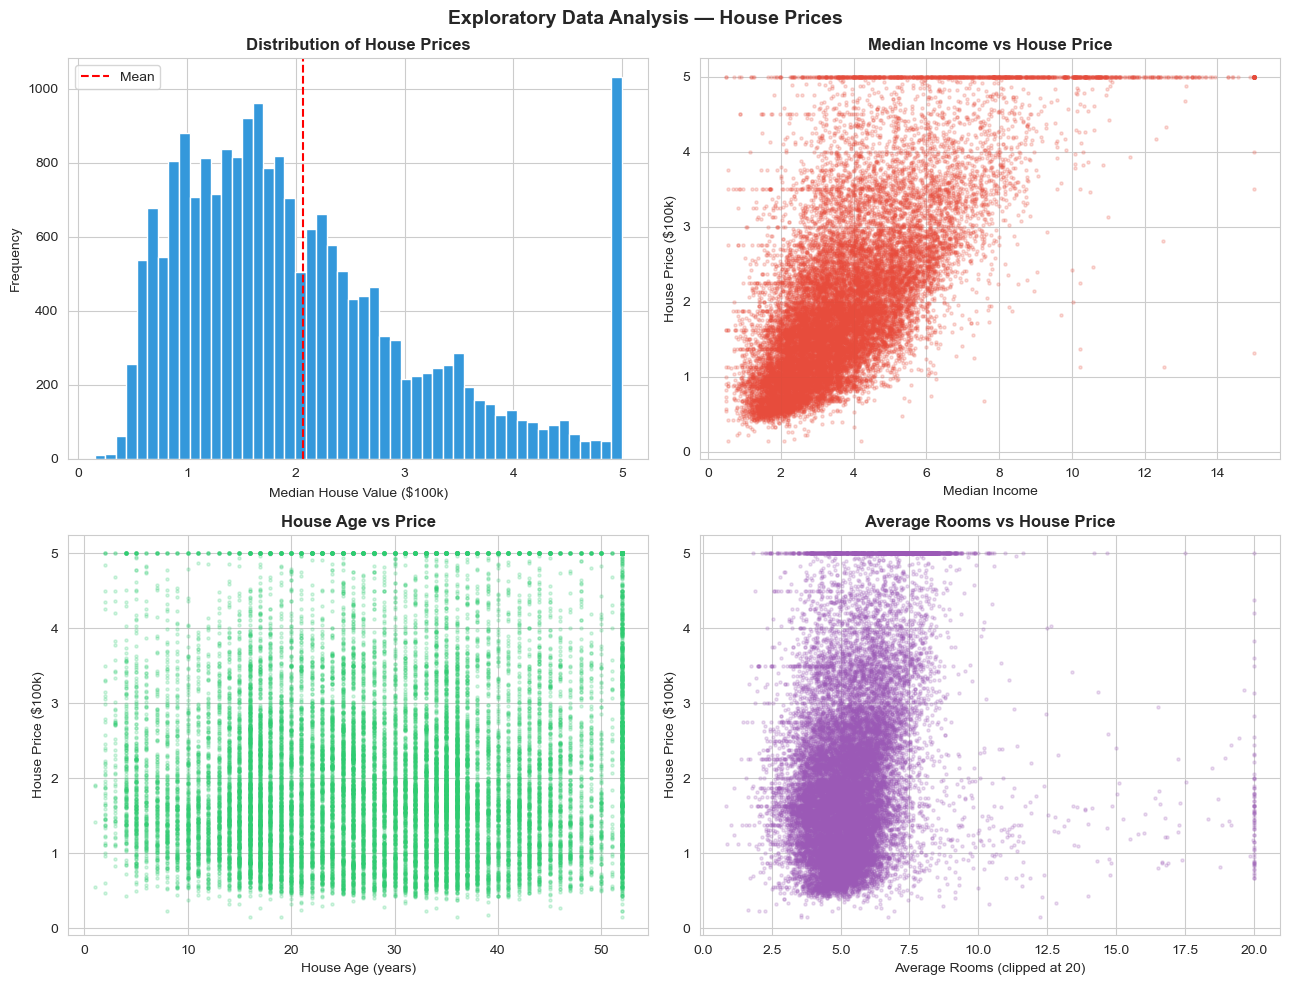

✅ EDA Completed & Saved as 'eda_house.png'


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()   

# ==========================================
#  1. Target distribution

axes[0].hist(df["MedHouseVal"], bins=50, color="#3498db", edgecolor="white")
axes[0].set_title("Distribution of House Prices", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Median House Value ($100k)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(df["MedHouseVal"].mean(), color="red", linestyle="--", label="Mean")
axes[0].legend()

# ==========================================
#  2. Income vs Price

axes[1].scatter(df["MedInc"], df["MedHouseVal"], alpha=0.2, s=5, color="#e74c3c")
axes[1].set_title("Median Income vs House Price", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Median Income")
axes[1].set_ylabel("House Price ($100k)")

# ==========================================
#  3. House Age vs Price
# =========================================
axes[2].scatter(df["HouseAge"], df["MedHouseVal"], alpha=0.2, s=5, color="#2ecc71")
axes[2].set_title("House Age vs Price", fontsize=12, fontweight="bold")
axes[2].set_xlabel("House Age (years)")
axes[2].set_ylabel("House Price ($100k)")

# ==========================================
#  4. Avg Rooms vs Price

axes[3].scatter(
    df["AveRooms"].clip(upper=20),
    df["MedHouseVal"],
    alpha=0.2,
    s=5,
    color="#9b59b6"
)

axes[3].set_title("Average Rooms vs House Price", fontsize=12, fontweight="bold")
axes[3].set_xlabel("Average Rooms (clipped at 20)")
axes[3].set_ylabel("House Price ($100k)")

# ==========================================
#  Final Layout

plt.suptitle("Exploratory Data Analysis — House Prices", fontsize=14, fontweight="bold")

plt.tight_layout()

plt.savefig("eda_house.png", dpi=100, bbox_inches="tight")

plt.show()

print("✅ EDA Completed & Saved as 'eda_house.png'")

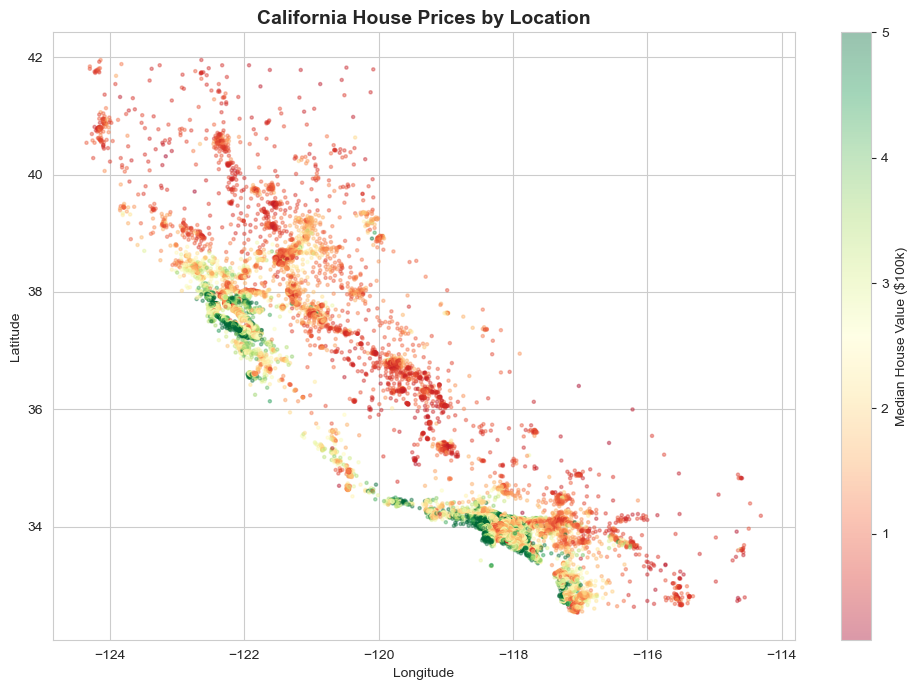

In [7]:
# Geographic visualization
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df["Longitude"], df["Latitude"],
                      c=df["MedHouseVal"], cmap="RdYlGn",
                      s=5, alpha=0.4)
plt.colorbar(scatter, label="Median House Value ($100k)")
plt.title("California House Prices by Location", fontsize=14, fontweight="bold")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.savefig("geo_map.png", dpi=100, bbox_inches="tight")
plt.show()

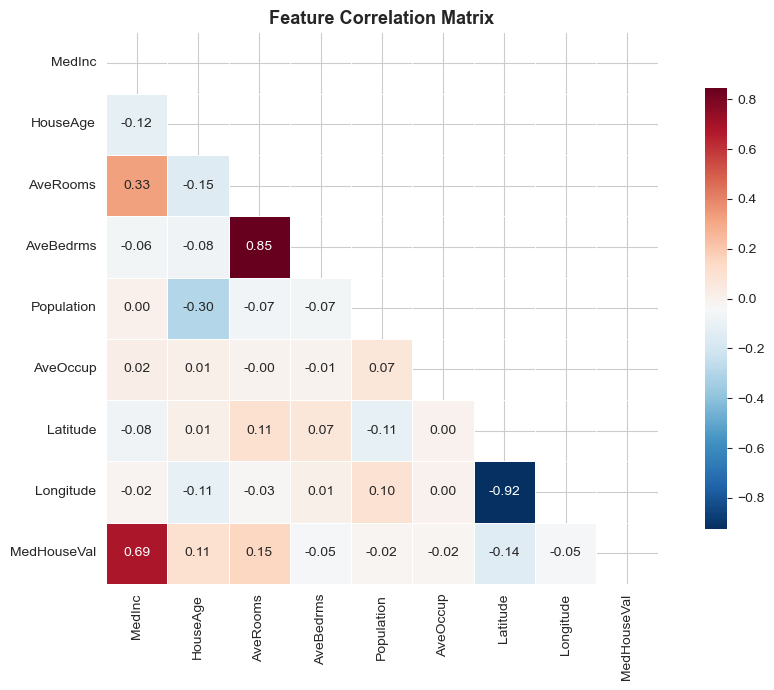

In [8]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            mask=mask, linewidths=0.5, square=True,
            cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_house.png", dpi=100, bbox_inches="tight")
plt.show()

## Step 5: Feature Engineering & Preprocessing

In [9]:
# Feature engineering
df["RoomsPerPerson"]    = df["AveRooms"] / df["AveOccup"]
df["BedroomsPerRoom"]   = df["AveBedrms"] / df["AveRooms"]

feature_cols = ["MedInc", "HouseAge", "AveRooms", "AveBedrms",
                "Population", "AveOccup", "Latitude", "Longitude",
                "RoomsPerPerson", "BedroomsPerRoom"]

X = df[feature_cols]
y = df["MedHouseVal"]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"Features used    : {feature_cols}")

Training samples : 16512
Testing  samples : 4128
Features used    : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'RoomsPerPerson', 'BedroomsPerRoom']


## Step 6: Train Models

In [10]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"  {name:25s} -> MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
    return mae, rmse, r2

# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

# Model 2: Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                max_depth=5, random_state=42)
gb.fit(X_train_scaled, y_train)
gb_preds = gb.predict(X_test_scaled)

# Model 3: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)

print("MODEL EVALUATION RESULTS:")
print("-" * 65)
lr_metrics = evaluate("Linear Regression",   y_test, lr_preds)
gb_metrics = evaluate("Gradient Boosting",   y_test, gb_preds)
rf_metrics = evaluate("Random Forest",       y_test, rf_preds)

MODEL EVALUATION RESULTS:
-----------------------------------------------------------------
  Linear Regression         -> MAE: 0.4862 | RMSE: 0.6753 | R2: 0.6519
  Gradient Boosting         -> MAE: 0.3101 | RMSE: 0.4692 | R2: 0.8320
  Random Forest             -> MAE: 0.3287 | RMSE: 0.5048 | R2: 0.8055


## Step 7: Visualize Predicted vs Actual Prices

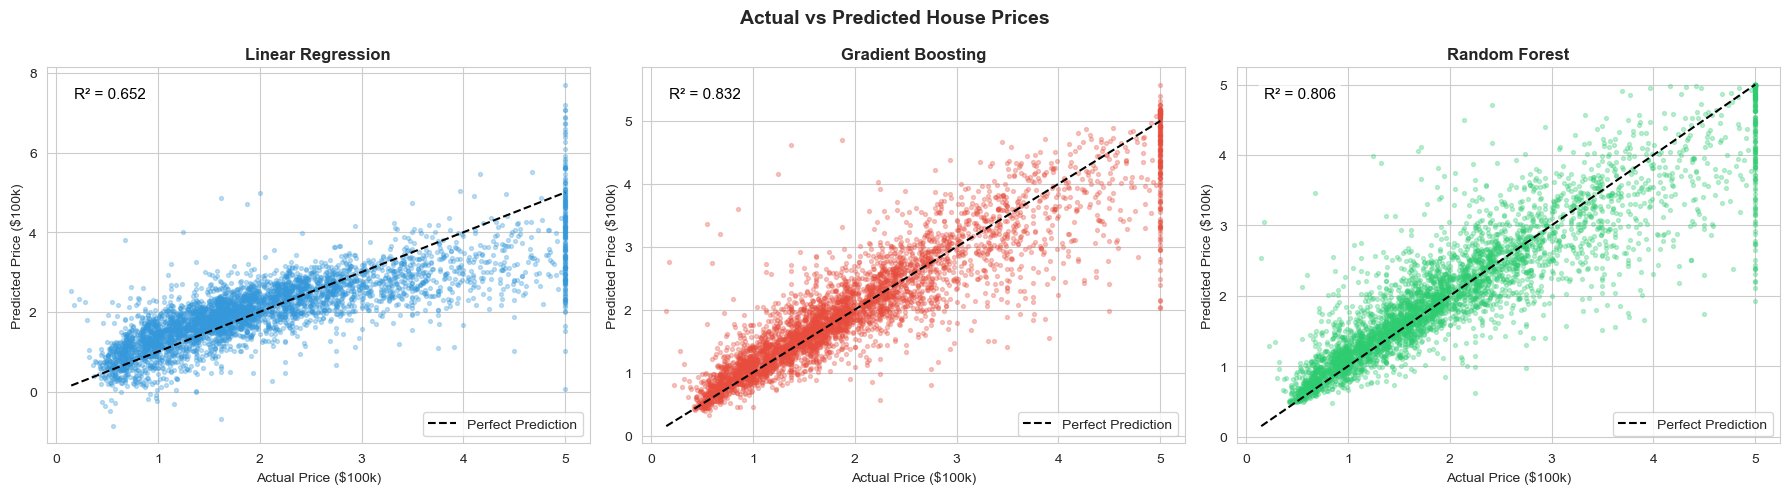

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, preds, name, color in [
    (axes[0], lr_preds, "Linear Regression", "#3498db"),
    (axes[1], gb_preds, "Gradient Boosting", "#e74c3c"),
    (axes[2], rf_preds, "Random Forest",     "#2ecc71")
]:
    ax.scatter(y_test, preds, alpha=0.3, s=8, color=color)
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], "k--", linewidth=1.5, label="Perfect Prediction")
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Actual Price ($100k)")
    ax.set_ylabel("Predicted Price ($100k)")
    r2 = r2_score(y_test, preds)
    ax.annotate(f"R² = {r2:.3f}", xy=(0.05, 0.92), xycoords="axes fraction",
                fontsize=11, color="black",
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))
    ax.legend()

plt.suptitle("Actual vs Predicted House Prices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=100, bbox_inches="tight")
plt.show()

## Step 8: Feature Importance

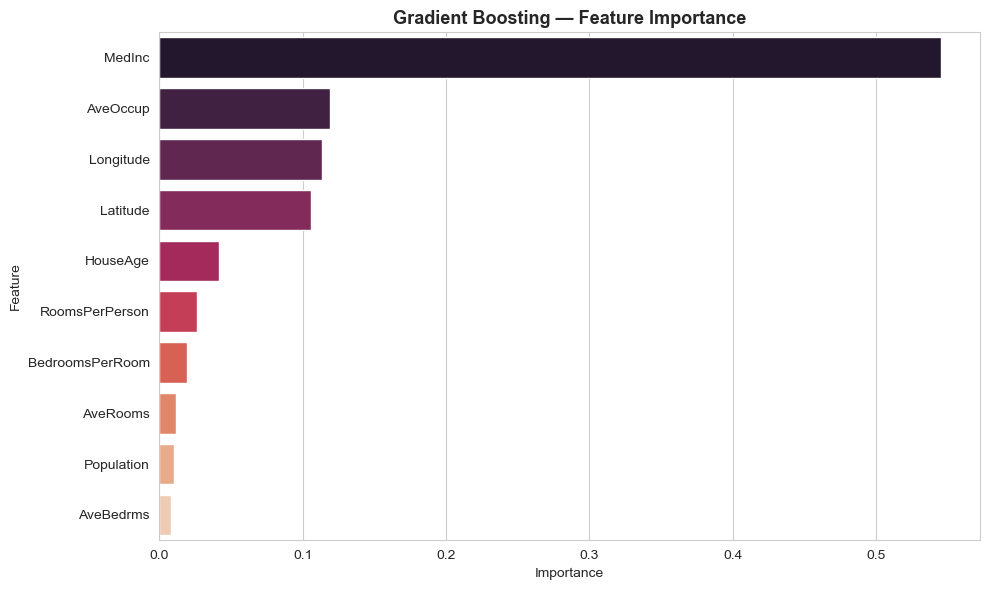

Feature Importance Rankings:
        Feature  Importance
         MedInc    0.545274
       AveOccup    0.118685
      Longitude    0.113656
       Latitude    0.105523
       HouseAge    0.041353
 RoomsPerPerson    0.026150
BedroomsPerRoom    0.019454
       AveRooms    0.011886
     Population    0.010055
      AveBedrms    0.007966


In [12]:
# Gradient Boosting feature importances
gb_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": gb.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=gb_importance, x="Importance", y="Feature",
            palette="rocket")
plt.title("Gradient Boosting — Feature Importance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance_house.png", dpi=100, bbox_inches="tight")
plt.show()

print("Feature Importance Rankings:")
print(gb_importance.to_string(index=False))

## Step 9: Key Insights & Conclusions

In [13]:
print("="*60)
print("KEY INSIGHTS - HOUSE PRICE PREDICTION")
print("="*60)
print()
print(f"Dataset: California Housing | {len(df):,} properties")
print()
print("MODEL PERFORMANCE (on test set):")
print(f"  Linear Regression  -> MAE: {lr_metrics[0]:.4f} | RMSE: {lr_metrics[1]:.4f} | R2: {lr_metrics[2]:.4f}")
print(f"  Gradient Boosting  -> MAE: {gb_metrics[0]:.4f} | RMSE: {gb_metrics[1]:.4f} | R2: {gb_metrics[2]:.4f}")
print(f"  Random Forest      -> MAE: {rf_metrics[0]:.4f} | RMSE: {rf_metrics[1]:.4f} | R2: {rf_metrics[2]:.4f}")
print()
print("KEY FINDINGS:")
print("  1. Median income is the #1 predictor of house value")
print("  2. Location (Latitude/Longitude) is highly important")
print("  3. Gradient Boosting outperforms Linear Regression by far")
print("  4. Feature engineering (RoomsPerPerson) adds predictive power")
print()
print("CONCLUSION:")
print("  Gradient Boosting is the best model for house price prediction.")
print("  Non-linear models capture complex spatial pricing patterns.")

KEY INSIGHTS - HOUSE PRICE PREDICTION

Dataset: California Housing | 20,640 properties

MODEL PERFORMANCE (on test set):
  Linear Regression  -> MAE: 0.4862 | RMSE: 0.6753 | R2: 0.6519
  Gradient Boosting  -> MAE: 0.3101 | RMSE: 0.4692 | R2: 0.8320
  Random Forest      -> MAE: 0.3287 | RMSE: 0.5048 | R2: 0.8055

KEY FINDINGS:
  1. Median income is the #1 predictor of house value
  2. Location (Latitude/Longitude) is highly important
  3. Gradient Boosting outperforms Linear Regression by far
  4. Feature engineering (RoomsPerPerson) adds predictive power

CONCLUSION:
  Gradient Boosting is the best model for house price prediction.
  Non-linear models capture complex spatial pricing patterns.
